In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from utils import *

data = load_data("data")

# Binary Modulation of V1 Responses

Running modulation of V1 responses across drifting gratings (DG), static gratings (SG), natural scenes (NS), and spontaneous activity, measured in 47 matched cells. Analysis code lives in `utils.py`; stimuli are extracted and analyzed separately and trials are never pooled across stimulus classes.

In [ ]:
DENOM_THRESHOLD = 1e-3   # historical raw-MI filter, diagnostic only
EPSILON = 1e-12          # sign-safe MI denominator constant

modulation_results = run_binary_modulation_analysis(
    data,
    RESPONSE_WINDOWS,
    run_threshold=3.0,
    still_threshold=0.5,
    min_trials_per_state=2,
)

## 0 Data and metric definition

### Trial classification

Each trial is assigned a behavioral state from its running-speed trace. Running trials have mean speed above 3.0 cm/s with every frame above 0.5 cm/s; still trials have mean speed below 0.5 cm/s with every frame below 3.0 cm/s; all remaining trials are ignored.

In [3]:
run_summary = summarize_binary_modulation_runs(modulation_results)
run_summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]]

,stimulus,n_trials,n_running,n_still,n_ignored
0,drifting_gratings,598,195,28,375
1,static_gratings,5811,1825,2722,1264
2,natural_scenes,5900,1315,2997,1588
3,spontaneous,296,44,26,226


Both states are populated in every stimulus, so the running-versus-still contrast is defined throughout. The balance is strongly skewed for DG, which retains only 28 still trials against 195 running trials, whereas SG and NS retain thousands of each. DG estimates therefore rest on far less still data than the other stimuli.

###  Raw MI and its limitation

The raw modulation index is defined as 

$$
MI_{\mathrm{raw}} = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}{R_{\mathrm{run}} + R_{\mathrm{still}}}
$$

where R_run and R_still are mean ΔF/F over the response window. This is bounded in [-1, 1] only for non-negative responses, but ΔF/F is signed, so the denominator can approach zero or become negative. The scatter below compares MI_raw against the sign-safe metric defined in Section 3.1, on a symlog axis because the raw values span several orders of magnitude.

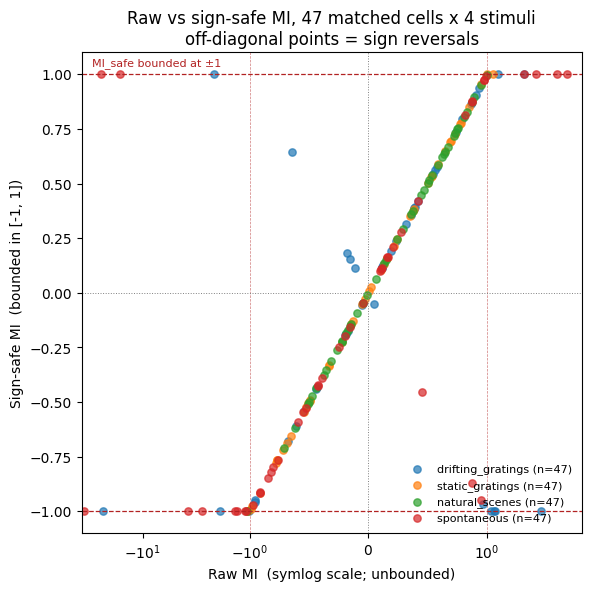

In [4]:
mi_version_summary = summarize_mi_versions(modulation_results, epsilon=EPSILON)
neg_df = get_negative_response_cells(modulation_results)

mi_safe_by_stimulus = {}
for stimulus in modulation_results:
    mi_safe_by_stimulus[stimulus], _, _ = compute_sign_safe_mi(modulation_results[stimulus], epsilon=EPSILON)

fig, ax = plt.subplots(figsize=(5.8, 5.8), constrained_layout=True)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, stimulus in enumerate(modulation_results):
    mi_raw = modulation_results[stimulus].mi
    mi_safe = mi_safe_by_stimulus[stimulus]
    valid = np.isfinite(mi_raw) & np.isfinite(mi_safe)
    ax.scatter(mi_raw[valid], mi_safe[valid], alpha=0.7, s=28,
               label=f"{stimulus} (n={int(valid.sum())})", color=colors[i % len(colors)])

for y in (-1, 1):
    ax.axhline(y, linestyle="--", color="firebrick", linewidth=0.9)
for x in (-1, 1):
    ax.axvline(x, linestyle="--", color="firebrick", linewidth=0.5, alpha=0.6)
ax.axhline(0, linestyle=":", color="gray", linewidth=0.7)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.7)
ax.set_xscale("symlog", linthresh=1)
ax.text(0.02, 0.99, "MI_safe bounded at ±1", transform=ax.transAxes, ha="left", va="top",
        fontsize=8, color="firebrick")
ax.set_xlabel("Raw MI  (symlog scale; unbounded)")
ax.set_ylabel("Sign-safe MI  (bounded in [-1, 1])")
ax.set_title("Raw vs sign-safe MI, 47 matched cells x 4 stimuli\noff-diagonal points = sign reversals")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.show()

In [5]:
raw_all = np.concatenate([modulation_results[s].mi[np.isfinite(modulation_results[s].mi)] for s in modulation_results])
raw_diagnostic = pd.DataFrame([{
    "raw_MI_min": float(raw_all.min()),
    "raw_MI_max": float(raw_all.max()),
    "n_outside_pm1": int((np.abs(raw_all) > 1).sum()),
    "n_observations": int(len(raw_all)),
    "n_negative_denominator": int(mi_version_summary["n_negative_raw_denominator"].sum()),
    "n_sign_reversal": int(mi_version_summary["n_raw_sign_reversal"].sum()),
}])
raw_diagnostic

,raw_MI_min,raw_MI_max,n_outside_pm1,n_observations,n_negative_denominator,n_sign_reversal
0,-35.263798,5.663002,27,188,16,16


In [6]:
example = (
    neg_df[(neg_df["stimulus"] == "drifting_gratings") & neg_df["sign_reversal"]]
    .assign(abs_mi=lambda d: d["mi"].abs())
    .sort_values("abs_mi", ascending=False)
    .iloc[0]
)
print(
    f"Sign-reversal example -- drifting_gratings cell {int(example['cell'])}:\n"
    f"  R_run = {example['r_run']:+.4f}, R_still = {example['r_still']:+.4f}\n"
    f"  denominator = {example['denominator']:+.4f} (negative)\n"
    f"  delta_R     = {example['delta_r']:+.4f} (run below still: suppression)\n"
    f"  raw MI      = {example['mi']:+.4f} (positive, and |MI| > 1)"
)

Sign-reversal example -- drifting_gratings cell 46:
  R_run = -0.0024, R_still = +0.0012
  denominator = -0.0011 (negative)
  delta_R     = -0.0036 (run below still: suppression)
  raw MI      = +3.1788 (positive, and |MI| > 1)


Raw MI is unstable for signed ΔF/F because near-zero or negative denominators produce extreme values and sign reversals. The sign-safe metric remains bounded and preserves the direction of R_run - R_still without discarding cells.

####  Negative-response structure

The instability above arises from cells with small or negative mean ΔF/F. This section examines whether those negative responses carry reproducible structure, in order to decide whether they can be removed. Five affected DG cells are inspected: the three with the largest |MI_raw| plus the two nearest the median |MI_raw|.

In [7]:
dg_neg = neg_df[
    (neg_df["stimulus"] == "drifting_gratings") & neg_df["negative_denominator"]
].reset_index(drop=True)

dg_neg_ranked = dg_neg.reindex(dg_neg["mi"].abs().sort_values(ascending=False).index).reset_index(drop=True)
top3_cells = dg_neg_ranked["cell"].tolist()[:3]

median_abs_mi = dg_neg["mi"].abs().median()
remaining = dg_neg[~dg_neg["cell"].isin(top3_cells)].copy()
remaining["dist"] = (remaining["mi"].abs() - median_abs_mi).abs()
median_cells = remaining.sort_values("dist")["cell"].tolist()[:2]

selected_cells = top3_cells + median_cells
print("Affected DG cells (negative denominator):", len(dg_neg))
print("Selected for inspection:", selected_cells)

dg_traces = extract_negative_trial_traces(
    modulation_results["drifting_gratings"], selected_cells, include_states=("running", "still")
)
print("Trial traces extracted:", len(dg_traces))

Affected DG cells (negative denominator): 11
Selected for inspection: [46, 3, 0, 24, 13]
Trial traces extracted: 1115


#####  Example traces

Individual trial traces for two representative selected cells, Cell 24 at the median |MI_raw| and Cell 13, with state means and ±1 SD variability bands.

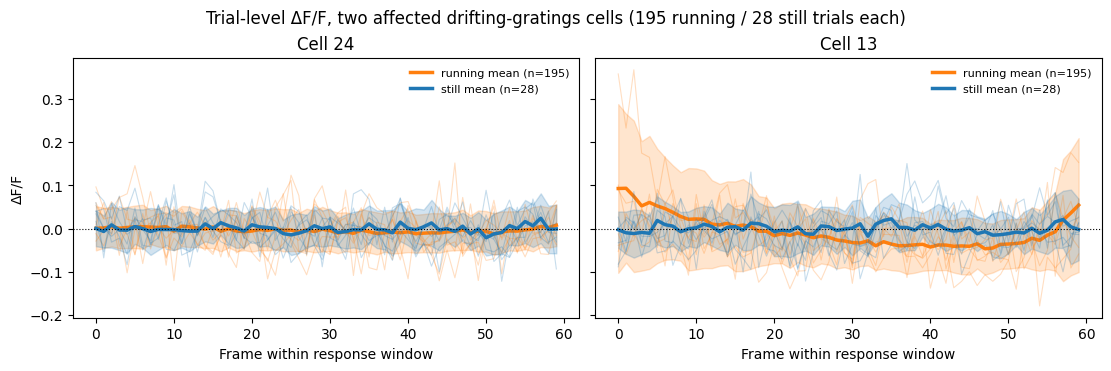

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, constrained_layout=True)
for ax, cell in zip(axes, [24, 13]):
    plot_negative_trace_examples(dg_traces, cell, n_examples=6, ax=ax)
axes[1].set_ylabel("")
fig.suptitle("Trial-level ΔF/F, two affected drifting-gratings cells (195 running / 28 still trials each)")
plt.show()

Cell 24 is dominated by near-zero, weakly reproducible fluctuations, whereas Cell 13 shows modest running-related temporal structure. Negative responses therefore differ across neurons and cannot all be assigned the same interpretation.

##### PCA summary

PCA over all 1115 selected trial traces, with rows as trials and columns as frames. Time-point features are standardized and per-trace means are retained, so sustained negative offsets are preserved.

Traces in PCA: 1115
Explained variance ratio (PC1-PC3): [0.1502 0.0915 0.0456]
Cumulative PC1-PC3: 28.7%


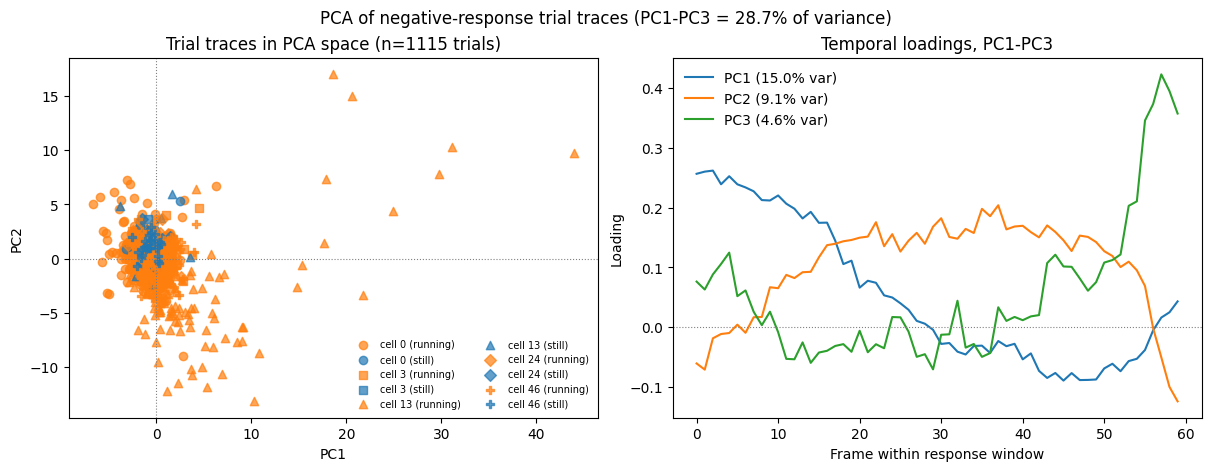

In [9]:
pca_scores, pca_components, pca_evr, pca_meta = run_negative_trace_pca(
    dg_traces, n_components=3, center_each_trace=False, scale_features=True
)
print("Traces in PCA:", pca_scores.shape[0])
print("Explained variance ratio (PC1-PC3):", np.round(pca_evr, 4))
print(f"Cumulative PC1-PC3: {100 * pca_evr.sum():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
plot_negative_trace_pca_scores(pca_scores, pca_meta, pc_x=0, pc_y=1, ax=axes[0])
axes[0].set_title(f"Trial traces in PCA space (n={pca_scores.shape[0]} trials)")
plot_negative_trace_pcs(pca_components, pca_evr, n_show=3, ax=axes[1])
axes[1].set_title("Temporal loadings, PC1-PC3")
fig.suptitle(f"PCA of negative-response trial traces (PC1-PC3 = {100*pca_evr.sum():.1f}% of variance)")
plt.show()

The first three PCs explained about 29% of trial-level variance, and running and still trials did not form distinct groups. The dominant structure was more cell-specific than state-specific, with Cell 13 providing the clearest exception.

##### Pairwise correlation

Mean pairwise Pearson correlation between trial traces within each cell and state, measuring trial-to-trial reproducibility.

In [10]:
reliability_rows = []
for (cell, state), g in dg_traces.groupby(["cell", "state"]):
    mat = np.vstack(g["trace"].to_numpy())
    if mat.shape[0] < 2:
        continue
    corr = np.corrcoef(mat)
    iu = np.triu_indices_from(corr, k=1)
    reliability_rows.append({
        "cell": cell,
        "state": state,
        "n_trials": mat.shape[0],
        "mean_pairwise_corr": float(np.nanmean(corr[iu])),
    })

reliability_df = pd.DataFrame(reliability_rows)
reliability_df

,cell,state,n_trials,mean_pairwise_corr
0,0,running,195,0.018956
1,0,still,28,0.006662
2,3,running,195,0.010668
3,3,still,28,0.012249
4,13,running,195,0.135742
5,13,still,28,0.003528
6,24,running,195,0.007592
7,24,still,28,-0.001427
8,46,running,195,0.009683
9,46,still,28,0.005397


Most cell-state groups showed near-zero trial-to-trial reproducibility, while Cell 13 showed modest structure during running.

Because negative responses are heterogeneous, they are retained rather than uniformly removed or shifted by an arbitrary baseline.

## 1 Sign-safe MI across stimuli

The primary normalized metric is 

$$
MI_{\mathrm{safe}} = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}
{|R_{\mathrm{run}}| + |R_{\mathrm{still}}| + \epsilon}
$$

with epsilon = 1e-12 preventing division by zero. Its denominator is never negative, so MI_safe is bounded in [-1, 1] and always carries the sign of R_run - R_still. The denominator-free sensitivity measure is delta_R = R_run - R_still.

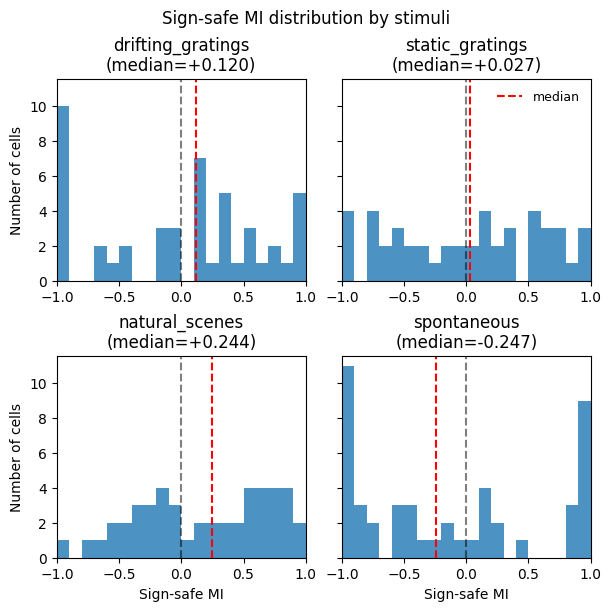

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6),
                         sharey=True, constrained_layout=True)
axes = axes.ravel()
for i, stimulus in enumerate(STIMULI):
    ax = axes[i]
    mi_safe, _, finite = compute_sign_safe_mi(modulation_results[stimulus], epsilon=EPSILON)
    vals = mi_safe[finite]
    median_safe = np.nanmedian(vals)

    ax.hist(vals, bins=20, range=(-1, 1), alpha=0.8, color="C0")
    ax.axvline(median_safe, linestyle="--", color="red", label=f"median")
    ax.axvline(0, linestyle="--", color="black", alpha=0.5,)
    ax.set_xlim(-1, 1)
    ax.set_title(f"{stimulus}\n(median={median_safe:+.3f})")
    if i%2==0:
        ax.set_ylabel("Number of cells")
    if i/2 >=1:
        ax.set_xlabel("Sign-safe MI")

    if i == 1:
        ax.legend(frameon=False, fontsize=9)
fig.suptitle("Sign-safe MI distribution by stimuli")

# plt.savefig("doc/figures/MI_histogram_populations.png")
plt.show()

Median sign-safe MI is positive for all three visually evoked stimuli and negative for spontaneous activity, so running is associated with enhanced evoked responses but suppressed no-stimulus activity. Natural scenes show the largest median modulation and static gratings the smallest. The effect is a population tendency rather than a universal one, since only 53 to 57 percent of cells are positive under evoked stimuli.

In [12]:
# --- Run t-test and identify significantly modulated neurons ---
alpha = 0.05
sig_rows = []
for stimulus in STIMULI:
    pvals = modulation_results[stimulus].t_pval
    finite_idx = np.isfinite(pvals)
    n_sig = int((pvals[finite_idx] < alpha).sum())
    n_total = int(finite_idx.sum())
    frac_sig = n_sig / n_total if n_total > 0 else 0.0
    sig_rows.append({
        "stimulus": stimulus,
        "n_significant": n_sig,
        "n_total": n_total,
        "frac_significant": f"{100*frac_sig:.1f}%",
    })

sig_df = pd.DataFrame(sig_rows)
sig_df

,stimulus,n_significant,n_total,frac_significant
0,drifting_gratings,4,47,8.5%
1,static_gratings,27,47,57.4%
2,natural_scenes,29,47,61.7%
3,spontaneous,0,0,0.0%


In [13]:
mi_safe_table = mi_version_summary[["stimulus", "median_safe_mi", "fraction_positive_safe_mi"]].copy()
mi_safe_table

,stimulus,median_safe_mi,fraction_positive_safe_mi
0,drifting_gratings,0.120017,0.553191
1,static_gratings,0.026739,0.531915
2,natural_scenes,0.244089,0.574468
3,spontaneous,-0.247195,0.425532


## 2 Gain analysis

The condition-level gain model fits 

$$
R_{\mathrm{run},c} = a \cdot R_{\mathrm{still},c} + b
$$

across stimulus conditions for each neuron, where a is the multiplicative slope, b is the additive offset, and R² measures how well one linear gain relation explains condition-level variation. A large slope does not imply a strong fit when R² is low, because the line can pass through a widely scattered cloud of conditions. Spontaneous activity has no condition structure and is excluded.

In [ ]:
stimulus = "natural_scenes"
analysis = modulation_results[stimulus]

eligible_cells = np.where(analysis.n_gain_conditions >= 10)[0]
population_median_r2 = np.nanmedian(analysis.gain_r2[np.isfinite(analysis.gain_r2)])
representative_cell = int(
    eligible_cells[np.nanargmin(np.abs(analysis.gain_r2[eligible_cells] - population_median_r2))]
)

analysis.plot_scatter(cell=representative_cell)
plt.show()

print(
    f"Representative {stimulus} cell {representative_cell}: "
    f"a = {analysis.gain_a[representative_cell]:.3f}, "
    f"b = {analysis.gain_b[representative_cell]:+.4f}, "
    f"R^2 = {analysis.gain_r2[representative_cell]:.3f} "
    f"(population median R^2 = {population_median_r2:.3f})"
)

In [15]:
df = summarize_gain_model(modulation_results)
df

,stimulus,n_valid_gain_fits,median_gain_a,median_gain_b,median_gain_r2,median_n_conditions,frac_gain_a_gt_1
0,drifting_gratings,47,0.109210,0.001252,0.107586,6.0,0.085106
1,static_gratings,47,0.273037,0.002341,0.053763,120.0,0.085106
2,natural_scenes,47,0.452296,0.009118,0.047038,118.0,0.234043


The representative cell was selected for having a typical R², and its fitted line is steep while its condition points scatter widely around it. Across the population median R² is only 0.05 to 0.11, so a single linear gain explains little condition-level variation. Natural scenes have the largest fraction of slopes above one, which is directionally consistent with their larger median MI but is not by itself evidence of multiplicative scaling given the weak fits.

## 3 Gratings versus natural scenes

For each matched cell the grating value is the mean of its DG and SG sign-safe MI, compared against its natural-scenes sign-safe MI with a paired Wilcoxon signed-rank test.

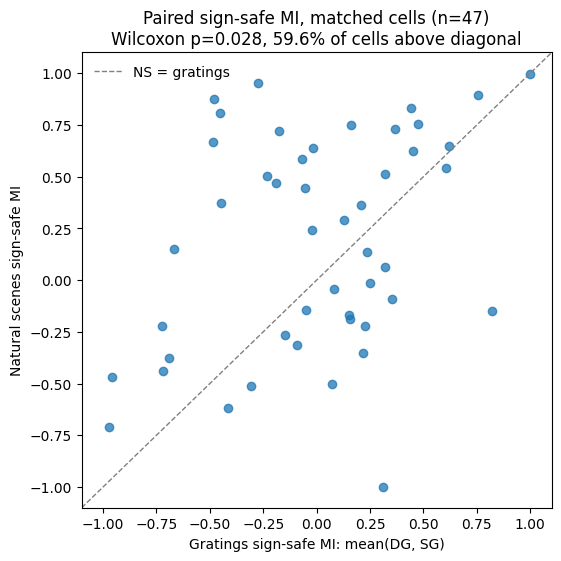

In [16]:
b6_signsafe_result, _, grating_values_safe, natural_values_safe = compare_gratings_vs_natural_signsafe(
    modulation_results, epsilon=EPSILON
)
p_value_signsafe = float(b6_signsafe_result["p_value"].iloc[0])

fig, ax = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)
plot_grating_natural_paired_scatter(grating_values_safe, natural_values_safe, p_value=p_value_signsafe, ax=ax)
ax.set_xlabel("Gratings sign-safe MI: mean(DG, SG)")
ax.set_ylabel("Natural scenes sign-safe MI")
ax.set_title(
    f"Paired sign-safe MI, matched cells (n={len(grating_values_safe)})\n"
    f"Wilcoxon p={p_value_signsafe:.3f}, "
    f"{100*float(b6_signsafe_result['frac_NS_greater_than_grating'].iloc[0]):.1f}% of cells above diagonal"
)
plt.show()

In [17]:
delta_dg = modulation_results["drifting_gratings"].r_run - modulation_results["drifting_gratings"].r_still
delta_sg = modulation_results["static_gratings"].r_run - modulation_results["static_gratings"].r_still
delta_ns = modulation_results["natural_scenes"].r_run - modulation_results["natural_scenes"].r_still
delta_grating = np.nanmean(np.vstack([delta_dg, delta_sg]), axis=0)
valid_delta = np.isfinite(delta_dg) & np.isfinite(delta_sg) & np.isfinite(delta_ns) & np.isfinite(delta_grating)
_, p_value_deltaR = wilcoxon(delta_grating[valid_delta], delta_ns[valid_delta])

b6_historical_result, _, _, _ = compare_gratings_vs_natural(modulation_results, denom_threshold=DENOM_THRESHOLD)

def _direction(g, n):
    return "NS > gratings" if np.nanmedian(n) > np.nanmedian(g) else "gratings > NS"

b6_sensitivity = pd.DataFrame([
    {"metric": "Sign-safe MI", "n_cells": int(b6_signsafe_result["n_cells"].iloc[0]),
     "direction": _direction(grating_values_safe, natural_values_safe),
     "p_value": round(p_value_signsafe, 3)},
    {"metric": "delta_R", "n_cells": int(valid_delta.sum()),
     "direction": _direction(delta_grating[valid_delta], delta_ns[valid_delta]),
     "p_value": round(float(p_value_deltaR), 3)},
    {"metric": "Historical raw/robust MI", "n_cells": int(b6_historical_result["n_cells"].iloc[0]),
     "direction": "NS > gratings" if float(b6_historical_result["median_difference_NS_minus_grating"].iloc[0]) > 0 else "gratings > NS",
     "p_value": round(float(b6_historical_result["p_value"].iloc[0]), 3)},
])
b6_sensitivity

,metric,n_cells,direction,p_value
0,Sign-safe MI,47,NS > gratings,0.028
1,delta_R,47,NS > gratings,0.208
2,Historical raw/robust MI,41,NS > gratings,0.389


All metrics agree in direction, with higher median modulation for natural scenes than for gratings, but only sign-safe MI is nominally significant. The result is therefore suggestive but not robust across metrics.

DG running and still trials cover different stimulus-condition sets, so aggregate DG modulation may partly reflect orientation or temporal-frequency tuning differences.

## 4 Allen validation

Sign-safe MI is compared against the Allen precomputed running-modulation indices `run_mod_dg`, `run_mod_sg`, and `run_mod_ns`, aligned by `cell_specimen_id` and correlated with Spearman rank correlation.

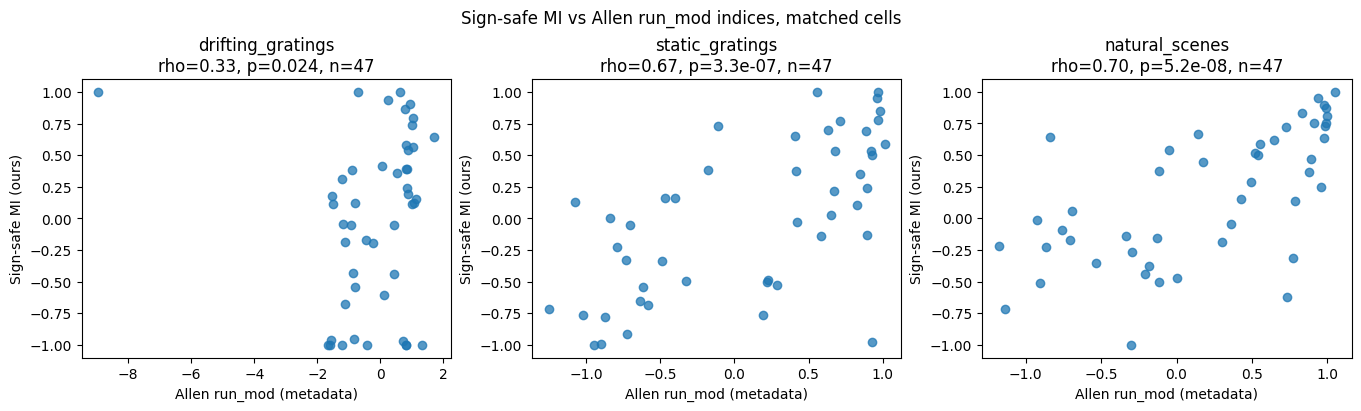

,stimulus,metadata_col,n_cells,spearman_rho,p_value
0,drifting_gratings,run_mod_dg,47,0.329093,2.390063e-02
1,static_gratings,run_mod_sg,47,0.665934,3.251418e-07
2,natural_scenes,run_mod_ns,47,0.697155,5.205690e-08


In [18]:
metadata = pd.read_csv("data/neurons_metadata.csv")

validation_df, aligned = validate_signsafe_mi_against_metadata(
    modulation_results, metadata, data["matched_cell_ids"], epsilon=EPSILON,
)

fig, axes = plot_metadata_validation(aligned, validation_df, ylabel="Sign-safe MI (ours)")
fig.suptitle("Sign-safe MI vs Allen run_mod indices, matched cells")
plt.show()

validation_df[["stimulus", "metadata_col", "n_cells", "spearman_rho", "p_value"]]

Agreement with the Allen running-modulation indices is strong for SG and NS and weaker for DG. The DG result should be interpreted cautiously because of its stimulus-condition imbalance.

##  Final conclusion

To compare running-related modulation across spontaneous activity and three visually evoked conditions, we first examined the raw responses. Because heterogeneous negative values made conventional MI unstable, we used sign-safe MI as the primary normalized metric, with $\Delta R$ as a denominator-free check. We also fitted a gain model,
$$
R_{\mathrm{run}} = aR_{\mathrm{still}} + b,
$$
where $a$ represents multiplicative gain and $b$ represents an additive shift.

1. **Running had opposite effects on evoked and spontaneous activity.** Median sign-safe MI was positive for SG, DG, and NS, but negative during the no-stimulus condition. This suggests that running enhanced visually evoked responses but suppressed spontaneous activity.

2. **Natural scenes showed the strongest modulation.** NS had the largest median modulation, while SG had the smallest. However, the exact difference between natural scenes and gratings depended on the metric. 

3. **The gain model suggested mainly multiplicative modulation.** The additive term \(b\) was close to zero, while the multiplicative term \(a\) differed across stimuli and was largest for NS. However, the low median $R^2$ values show that the model did not explain all neuron-level variation.

4. **The modulation_results were not equally robust across stimuli.** SG and NS agreed well with the Allen indices, while DG showed weaker agreement and should be interpreted with caution.

Overall, running was associated with stronger visually evoked activity and weaker spontaneous activity. Natural scenes showed the strongest modulation, and the gain-model modulation_results were more consistent with multiplicative than additive effects.

---

# Others by zhidong

## 1 'Tuned' neurons by binary conditions

compared with the one computed by SpeedTuning and/or the one by metadata
 

In [25]:
tuned_neurons = {short_stim:  np.where(modulation_results[stim].tuned_mask==True)[0] for (short_stim, stim) in zip(SHORT_STIM, STIMULI)}

for stim in STIMULI:
    print("========= ", stim, " ==========")
    modulation_results[stim].print_tuned_cells()

=========  drifting_gratings  ==========
Significantly tuned neurons: #4 
 [ 0 28 33 39]
  Cell 0: p = 0.02785
  Cell 28: p = 0.04694
  Cell 33: p = 0.01137
  Cell 39: p = 0.01933
=========  static_gratings  ==========
Significantly tuned neurons: #27 
 [ 0  1  4  6  9 11 13 14 15 16 17 20 21 23 25 27 28 29 30 36 37 38 40 43
 44 45 46]
  Cell 0: p = 0.04139
  Cell 1: p = 0.00014
  Cell 4: p = 0.00000
  Cell 6: p = 0.00034
  Cell 9: p = 0.03720
  Cell 11: p = 0.01176
  Cell 13: p = 0.00149
  Cell 14: p = 0.04994
  Cell 15: p = 0.00000
  Cell 16: p = 0.00000
  Cell 17: p = 0.00003
  Cell 20: p = 0.00041
  Cell 21: p = 0.00000
  Cell 23: p = 0.00020
  Cell 25: p = 0.00000
  Cell 27: p = 0.00299
  Cell 28: p = 0.00004
  Cell 29: p = 0.00000
  Cell 30: p = 0.00000
  Cell 36: p = 0.00002
  Cell 37: p = 0.00000
  Cell 38: p = 0.00002
  Cell 40: p = 0.01880
  Cell 43: p = 0.00083
  Cell 44: p = 0.00001
  Cell 45: p = 0.00413
  Cell 46: p = 0.00108
=========  natural_scenes  ==========
Signific

In [20]:
p_speed = metadata[[f'p_run_mod_{stim}' for stim in SHORT_STIM[:-1]]].values
mask_speed_tuned = p_speed < 0.05
np.sum(mask_speed_tuned, axis=0)
speed_tuned= {stim: np.where(mask_speed_tuned[:, i].T==True)[0] for (i, stim) in enumerate(SHORT_STIM[:-1])}
speed_tuned

{'dg': array([ 5,  6, 26, 28, 31, 37, 41]),
 'sg': array([ 2, 21, 24, 37, 39, 46]),
 'ns': array([ 1,  4,  9, 15, 21, 23, 24, 25, 27, 35, 37, 41, 44, 45, 46])}

In [21]:
tuned_neurons_mask = {short_stim: modulation_results[stim].tuned_mask for (short_stim, stim) in zip(SHORT_STIM, STIMULI)}
tuned_neurons_mask

{'dg': array([ True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False,  True, False, False,
        False, False, False,  True, False, False, False, False, False,
        False, False]),
 'sg': array([ True,  True, False, False,  True, False,  True, False, False,
         True, False,  True, False,  True,  True,  True,  True,  True,
        False, False,  True,  True, False,  True, False,  True, False,
         True,  True,  True,  True, False, False, False, False, False,
         True,  True,  True, False,  True, False, False,  True,  True,
         True,  True]),
 'ns': array([ True,  True, False,  True,  True, False, False, False,  True,
        False,  True,  True, False,  True, False,  True,  True, False,
         True, False,  True,  True, False,  True,  True,  True, False,
        Fal

In [22]:
for stim in SHORT_STIM[:-1]:
    print("======== ", stim, " =========")
    cpmputed_neurons = tuned_neurons[stim]
    metadata_neurons = speed_tuned[stim]
    print(f"{len(cpmputed_neurons)} vs {len(metadata_neurons)}")
    shared_neurons = np.intersect1d(cpmputed_neurons, metadata_neurons)
    print(f"{len(shared_neurons)} ", shared_neurons)

========  dg  =========
4 vs 7
1  [28]
========  sg  =========
27 vs 6
3  [21 37 46]
========  ns  =========
29 vs 15
11  [ 1  4 15 21 23 24 25 35 37 45 46]


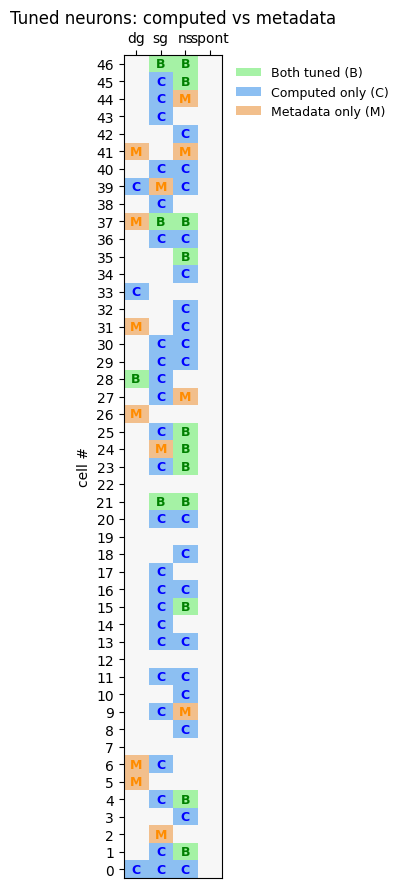

In [23]:
# ── Convert index arrays to boolean masks ──
n_cells = len(data["matched_cell_ids"])

tuned_masks = {
    stim: np.isin(np.arange(n_cells), tuned_neurons[stim])
    for stim in SHORT_STIM
}

speed_tuned_masks = {
    stim: np.isin(np.arange(n_cells), speed_tuned[stim])
    for stim in SHORT_STIM[:-1]  # spont has no metadata
}

# ── Plot grid: computed (t-test) vs metadata (p_run_mod) ──
fig = plot_tuned_neurons_grid(
    tuned_masks,
    metadata_tuned=speed_tuned_masks,
    figsize=(3.5, 9),
)
plt.show()

## 2 MI of the 'tuned' neurons

## 3 Gain model for the 'tuned' neurons